In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df = pd.read_csv("db/benchmark_results/eval/metrics_history.csv", sep=";")
df.head()

,id_turno,id_sessao,modelo,juiz,modo_rag,arquivo_origem,turno,style_rev,event_caus,adherence,time_order
0,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,gemini-2.5-flash_baseline_rep1,llama,Baseline (Sem RAG),transcript_adv_desert_01_gemini-2.5-flash_base...,1,0.875,0.750,1.00,0.625
1,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,gemini-2.5-flash_baseline_rep1,llama,Baseline (Sem RAG),transcript_adv_desert_01_gemini-2.5-flash_base...,2,0.800,0.750,0.95,0.775
2,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,gemini-2.5-flash_baseline_rep1,llama,Baseline (Sem RAG),transcript_adv_desert_01_gemini-2.5-flash_base...,3,0.800,0.775,0.95,0.625
3,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,gemini-2.5-flash_baseline_rep1,llama,Baseline (Sem RAG),transcript_adv_desert_01_gemini-2.5-flash_base...,4,0.800,0.750,0.95,0.750
4,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,gemini-2.5-flash_baseline_rep1,llama,Baseline (Sem RAG),transcript_adv_desert_01_gemini-2.5-flash_base...,5,0.875,0.858,1.00,0.800


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_turno        119 non-null    str    
 1   id_sessao       119 non-null    str    
 2   modelo          119 non-null    str    
 3   juiz            119 non-null    str    
 4   modo_rag        119 non-null    str    
 5   arquivo_origem  119 non-null    str    
 6   turno           119 non-null    int64  
 7   style_rev       119 non-null    float64
 8   event_caus      119 non-null    float64
 9   adherence       119 non-null    float64
 10  time_order      119 non-null    float64
dtypes: float64(4), int64(1), str(6)
memory usage: 10.4 KB


In [6]:
metricas = ['style_rev', 'event_caus', 'adherence', 'time_order']

## Agrupamento por arquitetura (RAG ou nao)

In [7]:
resumo_modo = df.groupby('modo_rag')[metricas].mean().reset_index()
print("Médias Gerais por Abordagem:")
print(resumo_modo)

Médias Gerais por Abordagem:
             modo_rag  style_rev  event_caus  adherence  time_order
0  Baseline (Sem RAG)   0.787712    0.768017   0.339831    0.652966
1          RAG Ligado   0.803750    0.783300   0.820417    0.736250


C:\Users\Admin\AppData\Local\Temp\ipykernel_5952\3193755519.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='modo_rag', y='event_caus', palette='Set2')


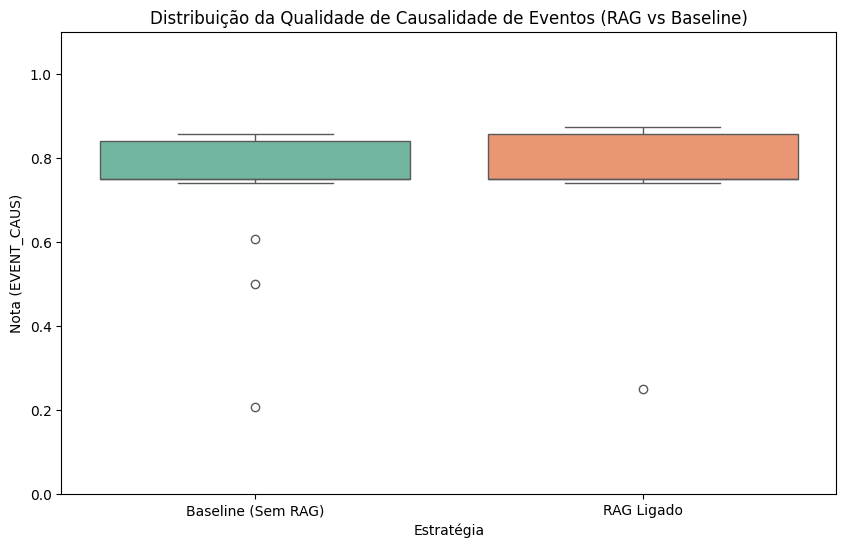

In [8]:
plt.figure(figsize=(10, 6))
# Exemplo focado na Causalidade de Eventos
sns.boxplot(data=df, x='modo_rag', y='event_caus', palette='Set2')

plt.title('Distribuição da Qualidade de Causalidade de Eventos (RAG vs Baseline)')
plt.ylabel('Nota (EVENT_CAUS)')
plt.xlabel('Estratégia')
plt.ylim(0, 1.1) # Padroniza o eixo Y de 0 a 1 (com um respiro)
plt.show()

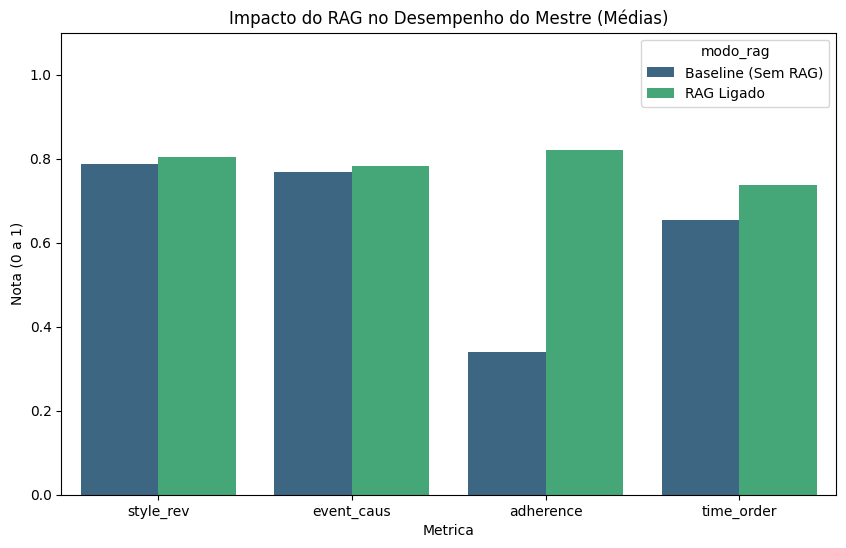

In [9]:
df_melted = df.melt(id_vars=['modo_rag'], 
                    value_vars=['style_rev', 'event_caus', 'adherence', 'time_order'], 
                    var_name='Metrica', value_name='Nota')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Metrica', y='Nota', hue='modo_rag', palette='viridis', errorbar=None)
plt.title('Impacto do RAG no Desempenho do Mestre (Médias)')
plt.ylabel('Nota (0 a 1)')
plt.ylim(0, 1.1)
plt.show()

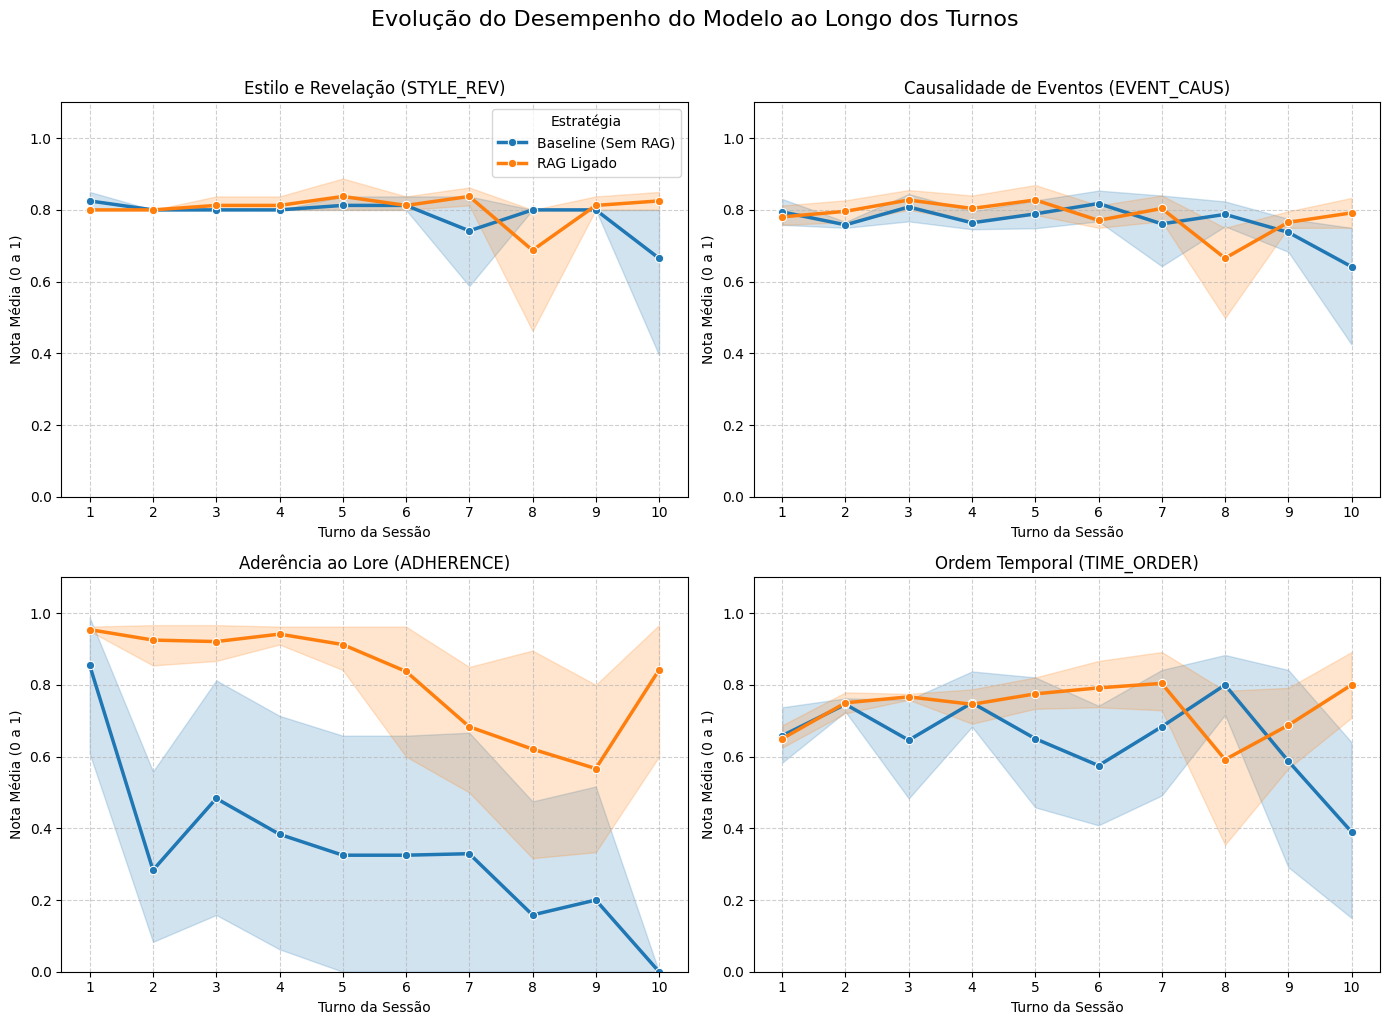

In [10]:
lista = ["style_rev", "event_caus", "adherence", "time_order"]
titulos = ["Estilo e Revelação", "Causalidade de Eventos", "Aderência ao Lore", "Ordem Temporal"]

# Cria uma figura grande com 2 linhas e 2 colunas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten() # Transforma a matriz 2x2 numa lista simples para facilitar o loop

# Define os turnos baseados nos seus dados
turnos_unicos = sorted(df['turno'].unique())

for i, metrica in enumerate(lista):
    # Passamos ax=axes[i] para dizer em qual "quadradinho" o gráfico vai ser desenhado
    sns.lineplot(data=df, x='turno', y=metrica, hue='modo_rag', marker='o', linewidth=2.5, ax=axes[i])
    
    axes[i].set_title(f'{titulos[i]} ({metrica.upper()})', fontsize=12)
    axes[i].set_xlabel('Turno da Sessão')
    axes[i].set_ylabel('Nota Média (0 a 1)')
    axes[i].set_xticks(turnos_unicos)
    axes[i].set_ylim(0, 1.1)
    axes[i].grid(True, linestyle='--', alpha=0.6)
    
    # Remove as legendas individuais de todos, exceto do primeiro, para não poluir
    if i == 0:
        axes[i].legend(title="Estratégia")
    else:
        if axes[i].get_legend() is not None:
            axes[i].get_legend().remove()

# Dá um título geral para a imagem inteira
plt.suptitle('Evolução do Desempenho do Modelo ao Longo dos Turnos', fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

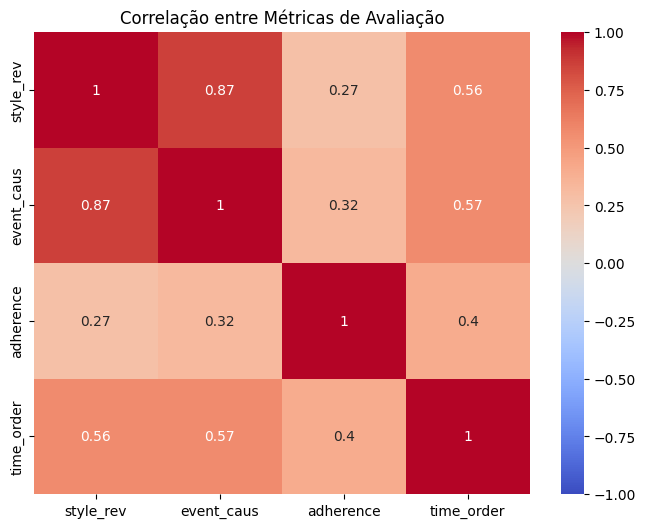

In [11]:
plt.figure(figsize=(8, 6))
# Filtramos apenas as colunas das métricas numéricas
metricas_df = df[['style_rev', 'event_caus', 'adherence', 'time_order']].astype(float)
sns.heatmap(metricas_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlação entre Métricas de Avaliação')
plt.show()

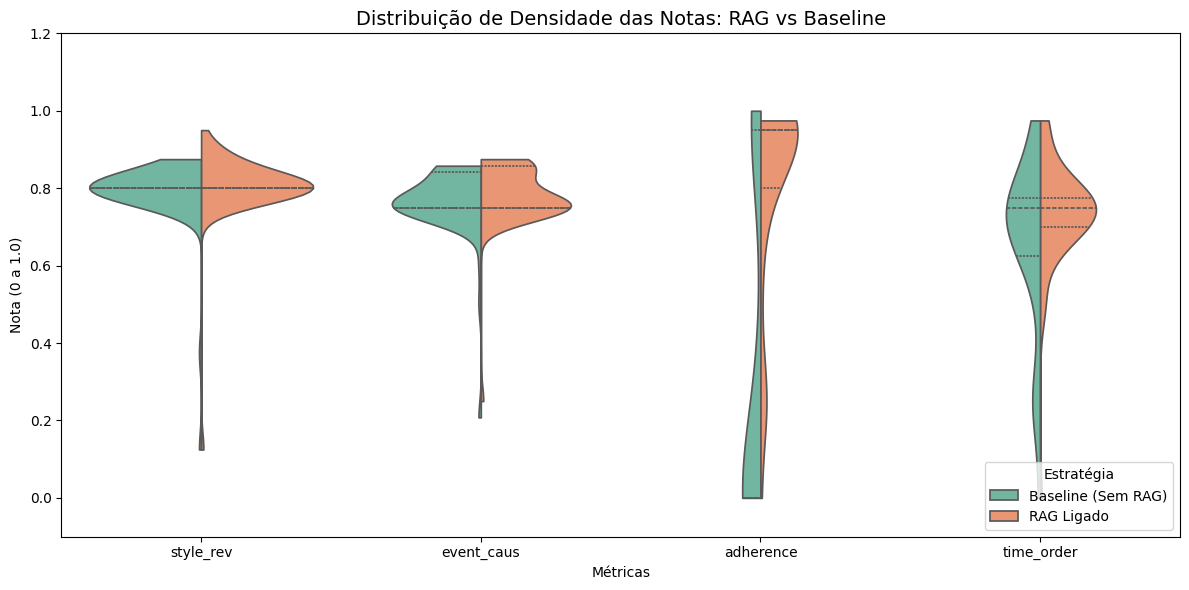

In [12]:
lista_metricas = ["style_rev", "event_caus", "adherence", "time_order"]
df_melted = df.melt(id_vars=['modo_rag'], value_vars=lista_metricas, var_name='Metrica', value_name='Nota')

plt.figure(figsize=(12, 6))
# O pulo do gato é o split=True e inner='quartile' (para mostrar a mediana)
sns.violinplot(
    data=df_melted, 
    x='Metrica', 
    y='Nota', 
    hue='modo_rag', 
    split=True, 
    inner='quartile', 
    palette='Set2',
    cut=0 # Impede que o gráfico desenhe notas além de 1.0 ou abaixo de 0.0
)

plt.title('Distribuição de Densidade das Notas: RAG vs Baseline', fontsize=14)
plt.ylabel('Nota (0 a 1.0)')
plt.xlabel('Métricas')
plt.ylim(-0.1, 1.2) # Margem de respiro
plt.legend(title='Estratégia', loc='lower right')

plt.tight_layout()
plt.show()

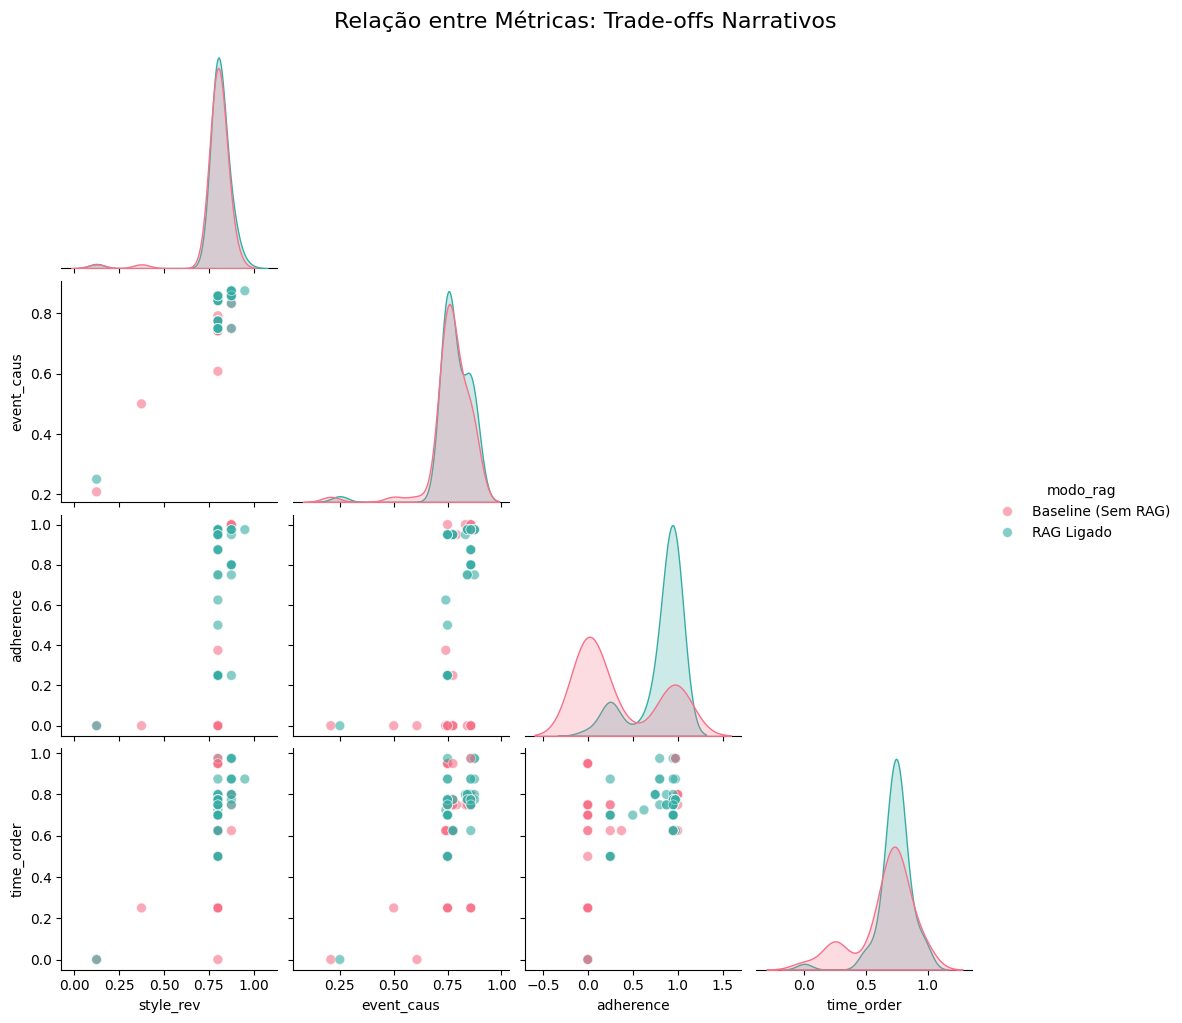

In [13]:
# Selecionamos apenas as colunas de métricas e a coluna de agrupamento
cols_para_plot = ["style_rev", "event_caus", "adherence", "time_order", "modo_rag"]

# corner=True remove os gráficos repetidos da parte superior, deixando com cara de artigo gringo
sns.pairplot(
    df[cols_para_plot], 
    hue='modo_rag', 
    palette='husl', 
    corner=True,
    plot_kws={'alpha': 0.6, 's': 50} # alpha deixa os pontos semi-transparentes
)

plt.suptitle('Relação entre Métricas: Trade-offs Narrativos', y=1.02, fontsize=16)
plt.show()

In [14]:
# Filtramos apenas as colunas que importam
analise_rapida = df.groupby('modo_rag')[['style_rev', 'event_caus', 'adherence', 'time_order']].mean()

print(analise_rapida)

                    style_rev  event_caus  adherence  time_order
modo_rag                                                        
Baseline (Sem RAG)   0.787712    0.768017   0.339831    0.652966
RAG Ligado           0.803750    0.783300   0.820417    0.736250


## Agrupamento por modelo que Mestrou

In [15]:
df_agg_modelo = df.groupby(['modelo', 'modo_rag','juiz'])[metricas].mean().reset_index()

print("Média de Desempenho por Modelo:")
print(df_agg_modelo)

Média de Desempenho por Modelo:
                             modelo            modo_rag   juiz  style_rev  \
0    gemini-2.5-flash_baseline_rep1  Baseline (Sem RAG)  llama   0.789655   
1         gemini-2.5-flash_rag_rep1          RAG Ligado  llama   0.807500   
2  openai_gpt-4o-mini_baseline_rep1  Baseline (Sem RAG)  llama   0.785833   
3       openai_gpt-4o-mini_rag_rep1          RAG Ligado  llama   0.800000   

   event_caus  adherence  time_order  
0    0.768034   0.336207    0.683621  
1    0.790500   0.854167    0.761667  
2    0.768000   0.343333    0.623333  
3    0.776100   0.786667    0.710833  


In [16]:
df_melted = df_agg_modelo.melt(id_vars=['modelo','juiz'], value_vars=metricas, var_name='Metrica', value_name='Nota')
df_melted.head()

,modelo,juiz,Metrica,Nota
0,gemini-2.5-flash_baseline_rep1,llama,style_rev,0.789655
1,gemini-2.5-flash_rag_rep1,llama,style_rev,0.807500
2,openai_gpt-4o-mini_baseline_rep1,llama,style_rev,0.785833
3,openai_gpt-4o-mini_rag_rep1,llama,style_rev,0.800000
4,gemini-2.5-flash_baseline_rep1,llama,event_caus,0.768034


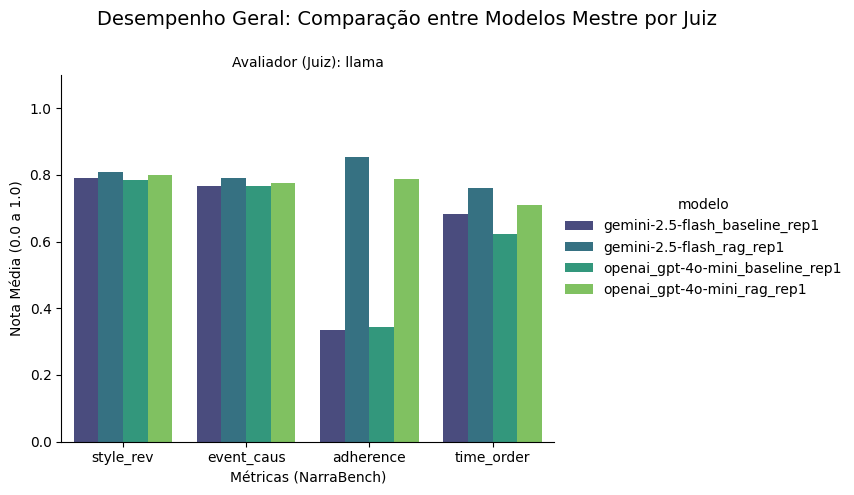

In [17]:
# O seu melt está certinho!
df_melted = df_agg_modelo.melt(id_vars=['modelo','juiz'], value_vars=metricas, var_name='Metrica', value_name='Nota')

# Usamos catplot passando col='juiz' para ele criar as subdivisões
g = sns.catplot(
    data=df_melted, 
    kind='bar',
    x='Metrica', 
    y='Nota', 
    hue='modelo', 
    col='juiz',        # <-- O SEGREDO ESTÁ AQUI (um gráfico para cada juiz)
    errorbar=None, 
    palette='viridis',
    height=5,          # Altura de cada gráfico
    aspect=1.2         # Largura de cada gráfico
)

# Ajustando os textos e eixos para ficar com cara de TCC
g.set_axis_labels("Métricas (NarraBench)", "Nota Média (0.0 a 1.0)")
g.set_titles("Avaliador (Juiz): {col_name}") # {col_name} vai ser substituído por 'groq' ou 'google'
g.set(ylim=(0, 1.1))

# Título global da figura
plt.subplots_adjust(top=0.85) # Dá um espacinho no topo
g.fig.suptitle('Desempenho Geral: Comparação entre Modelos Mestre por Juiz', fontsize=14)

plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_5952\4161951064.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='modelo', y='adherence', palette='Set3')


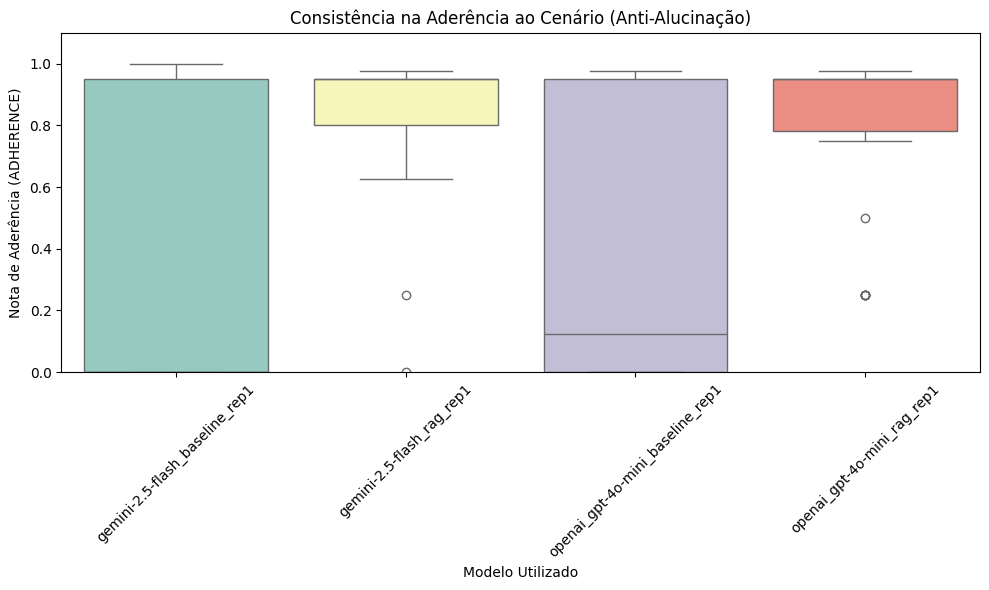

In [18]:
plt.figure(figsize=(10, 6))

# Exemplo focado na Fidelidade ao Lore (Adherence)
sns.boxplot(data=df, x='modelo', y='adherence', palette='Set3')

plt.title('Consistência na Aderência ao Cenário (Anti-Alucinação)')
plt.ylabel('Nota de Aderência (ADHERENCE)')
plt.xlabel('Modelo Utilizado')
plt.ylim(0, 1.1)

# Se os nomes dos modelos forem grandes (ex: "gemini-1.5-pro"), isto inclina o texto para não encavalar
plt.xticks(rotation=45) 

plt.tight_layout()
plt.show()

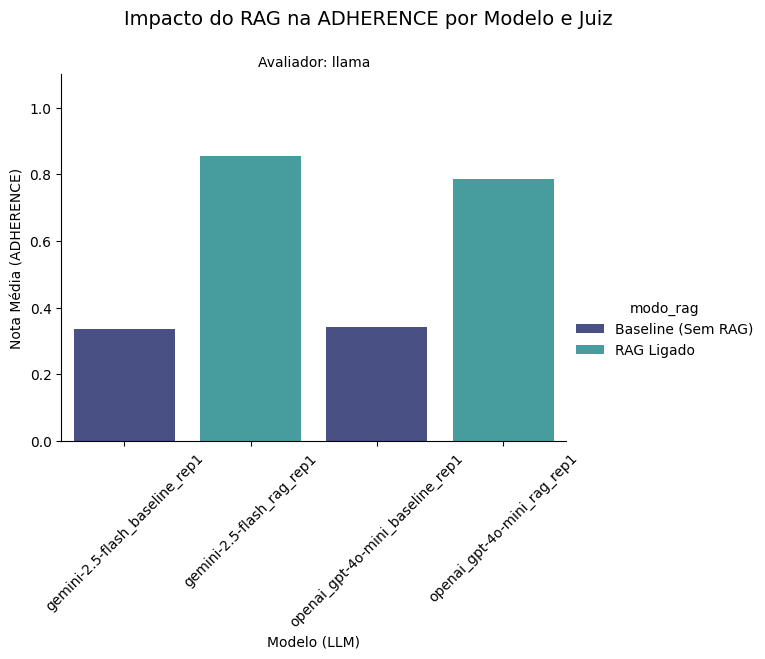

In [19]:
metrica_alvo = 'adherence'

# O catplot cria automaticamente painéis (colunas) para os juízes
g = sns.catplot(
    data=df_agg_modelo, 
    kind='bar',
    x='modelo', 
    y=metrica_alvo, 
    hue='modo_rag', 
    col='juiz',          # Cria um gráfico lado a lado para cada juiz
    palette='mako',      # Paleta de cores muito elegante para PDFs
    height=5, 
    aspect=1.2
)

# Ajustes de formatação para artigo acadêmico
g.set_axis_labels("Modelo (LLM)", f"Nota Média ({metrica_alvo.upper()})")
g.set_titles("Avaliador: {col_name}")
g.set(ylim=(0, 1.1))

# Inclina os nomes dos modelos para não sobrepor
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)

plt.subplots_adjust(top=0.85)
g.fig.suptitle(f'Impacto do RAG na {metrica_alvo.upper()} por Modelo e Juiz', fontsize=14)

plt.show()

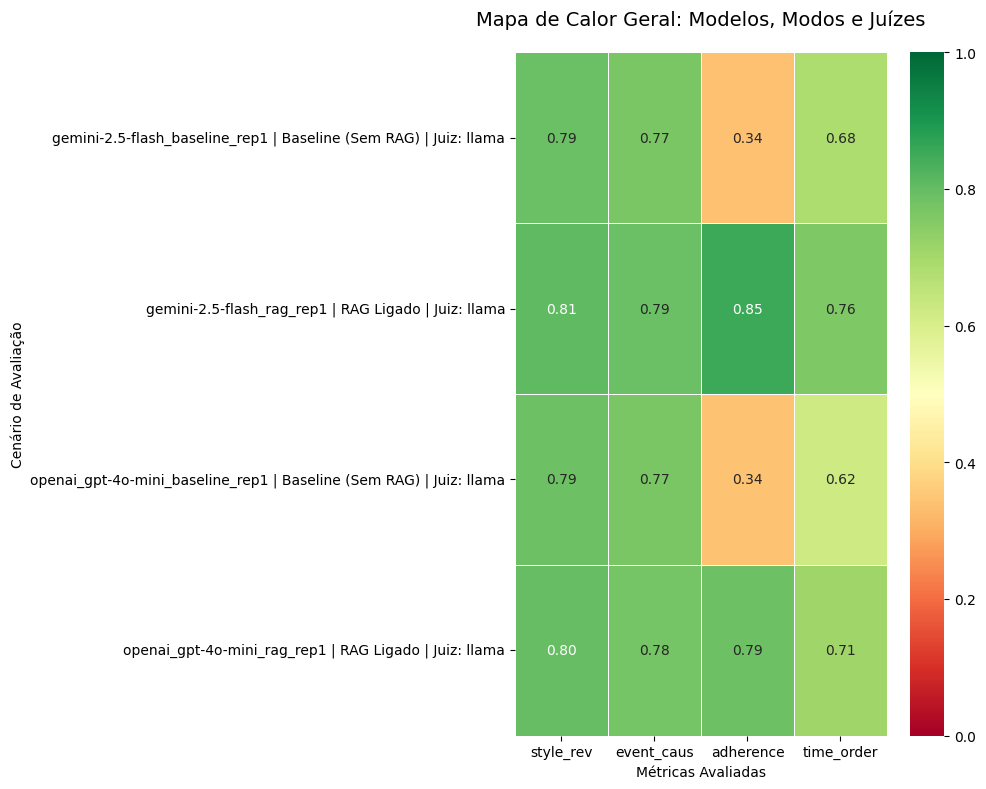

In [20]:
df_agg_modelo['Cenario'] = df_agg_modelo['modelo'] + " | " + df_agg_modelo['modo_rag'] + " | Juiz: " + df_agg_modelo['juiz']

# Colocamos o 'Cenario' como índice e selecionamos apenas as colunas das notas
tabela_heatmap = df_agg_modelo.set_index('Cenario')[metricas]

plt.figure(figsize=(10, 8))
# cmap='RdYlGn' vai do Vermelho (pior) para o Amarelo, até o Verde (melhor)
sns.heatmap(tabela_heatmap, annot=True, cmap='RdYlGn', fmt=".2f", vmin=0, vmax=1, linewidths=.5)

plt.title('Mapa de Calor Geral: Modelos, Modos e Juízes', fontsize=14, pad=20)
plt.xlabel('Métricas Avaliadas')
plt.ylabel('Cenário de Avaliação')
plt.tight_layout()
plt.show()

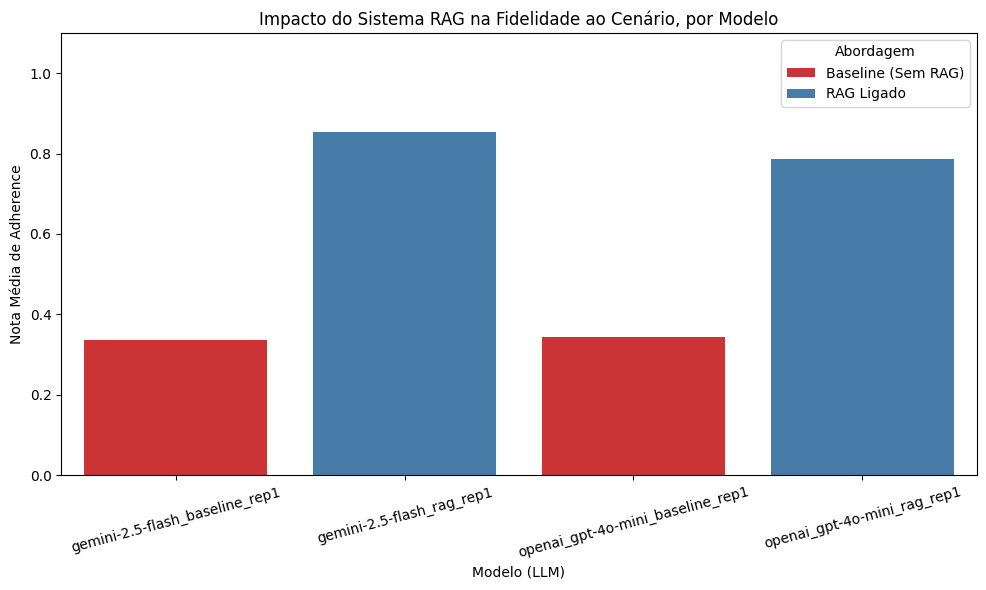

In [21]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df, 
    x='modelo', 
    y='adherence', 
    hue='modo_rag', # É aqui que a mágica acontece!
    palette='Set1',
    errorbar=None
)

plt.title('Impacto do Sistema RAG na Fidelidade ao Cenário, por Modelo')
plt.ylabel('Nota Média de Adherence')
plt.xlabel('Modelo (LLM)')
plt.ylim(0, 1.1)
plt.xticks(rotation=15) # Dá uma leve inclinada no nome dos modelos
plt.legend(title='Abordagem')

plt.tight_layout()
plt.show()

In [22]:
df_analise = df.groupby(['modelo', 'modo_rag'])[['style_rev', 'event_caus', 'adherence', 'time_order']].mean().reset_index()

print(df_analise)

                             modelo            modo_rag  style_rev  \
0    gemini-2.5-flash_baseline_rep1  Baseline (Sem RAG)   0.789655   
1         gemini-2.5-flash_rag_rep1          RAG Ligado   0.807500   
2  openai_gpt-4o-mini_baseline_rep1  Baseline (Sem RAG)   0.785833   
3       openai_gpt-4o-mini_rag_rep1          RAG Ligado   0.800000   

   event_caus  adherence  time_order  
0    0.768034   0.336207    0.683621  
1    0.790500   0.854167    0.761667  
2    0.768000   0.343333    0.623333  
3    0.776100   0.786667    0.710833  
